In [ ]:
# Package installation and loading

# Install CoolProp
!pip install CoolProp

# Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI
# Add more pakcages as needed


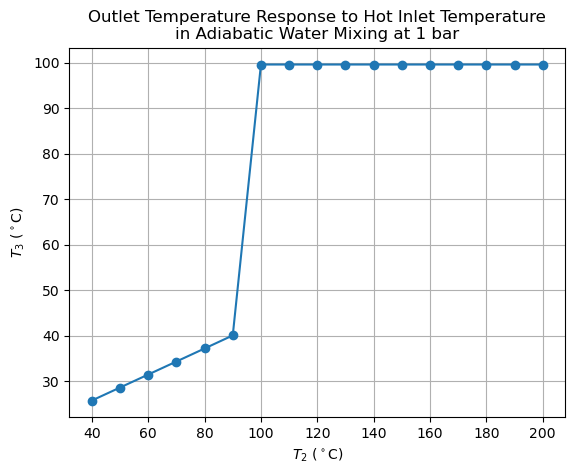

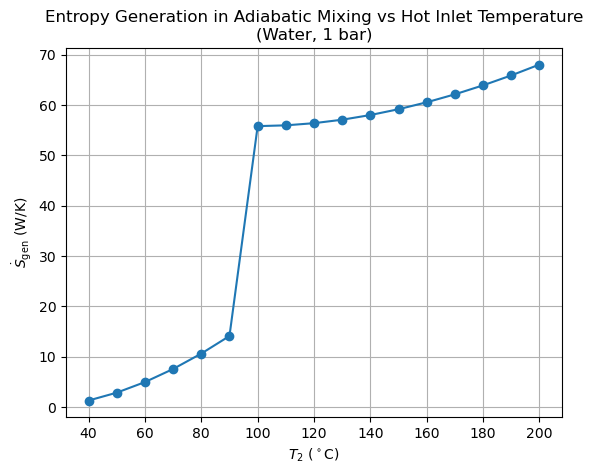

In [6]:
# Q1

# Given data
P = 1e5               # Pa (1 bar)
m1 = 0.50             # kg/s
m2 = 0.20             # kg/s
m3 = m1 + m2

T1_C = 20.0
T1 = T1_C + 273.15

# Stream 1 properties
h1 = PropsSI("H", "T", T1, "P", P, "Water")
s1 = PropsSI("S", "T", T1, "P", P, "Water")

# Arrays
T2_C_list = np.arange(40.0, 200.0 + 1e-6, 10.0)
T3_C_list = []
Sgen_list = []

for T2_C in T2_C_list:
    T2 = T2_C + 273.15
    
    h2 = PropsSI("H", "T", T2, "P", P, "Water")
    s2 = PropsSI("S", "T", T2, "P", P, "Water")
    
    # Energy balance - outlet enthalpy
    h3 = (m1*h1 + m2*h2) / m3
    
    # T3 from (P, h3)
    T3 = PropsSI("T", "P", P, "H", h3, "Water")
    T3_C = T3 - 273.15
    
    s3 = PropsSI("S", "P", P, "H", h3, "Water")
    
    # Entropy generation
    Sgen = m3*s3 - m1*s1 - m2*s2  # W/K
    
    T3_C_list.append(T3_C)
    Sgen_list.append(Sgen)

# Plot 1: Outlet temperature vs hot-inlet temperature
plt.figure()
plt.plot(T2_C_list, T3_C_list, marker='o')
plt.xlabel(r"$T_2\ (^\circ\mathrm{C})$")
plt.ylabel(r"$T_3\ (^\circ\mathrm{C})$")
plt.title("Outlet Temperature Response to Hot Inlet Temperature\nin Adiabatic Water Mixing at 1 bar")
plt.grid(True)

# Plot 2: Entropy generation vs hot-inlet temperature
plt.figure()
plt.plot(T2_C_list, Sgen_list, marker='o')
plt.xlabel(r"$T_2\ (^\circ\mathrm{C})$")
plt.ylabel(r"$\dot S_{\mathrm{gen}}\ (\mathrm{W/K})$")
plt.title("Entropy Generation in Adiabatic Mixing vs Hot Inlet Temperature\n(Water, 1 bar)")
plt.grid(True)

plt.show()


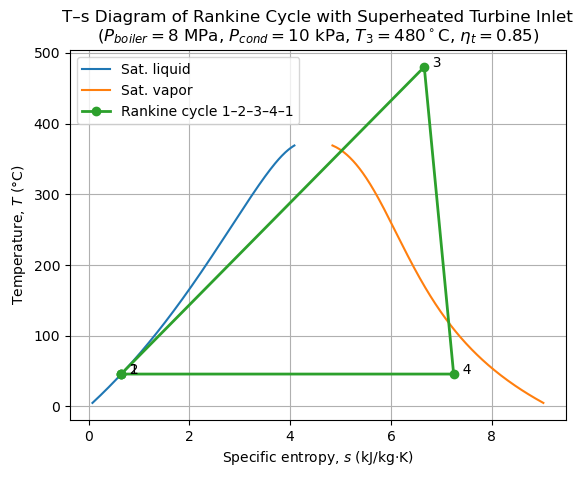

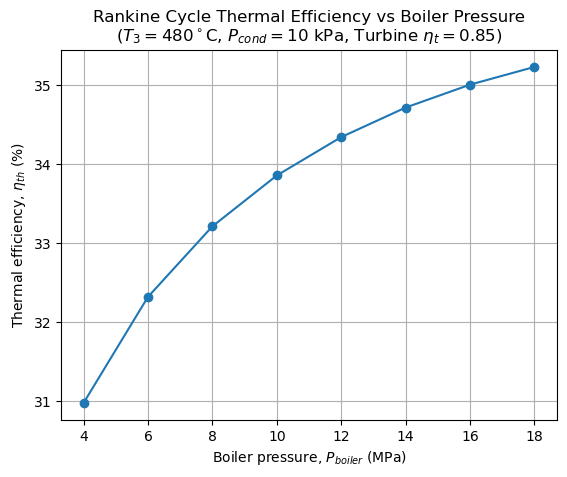

In [11]:
# Q2

# PART 1

# Given constants
P_cond = 10e3       # Pa
P_boiler = 8e6      # Pa
T3_C = 480.0
T3 = T3_C + 273.15

# State 1: saturated liquid at condenser pressure
h1 = PropsSI("H", "P", P_cond, "Q", 0, "Water")
s1 = PropsSI("S", "P", P_cond, "Q", 0, "Water")

# State 2: pump outlet (isentropic)
h2 = PropsSI("H", "P", P_boiler, "S", s1, "Water")
s2 = PropsSI("S", "P", P_boiler, "H", h2, "Water")

# State 3: boiler outlet (superheated)
h3 = PropsSI("H", "T", T3, "P", P_boiler, "Water")
s3 = PropsSI("S", "T", T3, "P", P_boiler, "Water")

# State 4: isentropic turbine exit
h4s = PropsSI("H", "P", P_cond, "S", s3, "Water")

eta_t = 0.85
h4 = h3 - eta_t * (h3 - h4s)
s4 = PropsSI("S", "P", P_cond, "H", h4, "Water")

# Convert to plotting units (degrees C and kJ/kg/K)
def K_to_C(T): return T - 273.15
h1k, h2k, h3k, h4k = np.array([h1,h2,h3,h4]) / 1e3
s1k, s2k, s3k, s4k = np.array([s1,s2,s3,s4]) / 1e3

# Get actual temperatures of 1,2,4 from (P, H)
T1 = PropsSI("T", "P", P_cond, "H", h1, "Water")
T2 = PropsSI("T", "P", P_boiler, "H", h2, "Water")
T4 = PropsSI("T", "P", P_cond, "H", h4, "Water")
T1C, T2C, T4C = map(K_to_C, [T1, T2, T4])

# Saturation dome
Tcrit = PropsSI("Tcrit", "Water")
Tsat_list = np.linspace(5.0 + 273.15, Tcrit - 5.0, 300)  # K
sL_list = []
sV_list = []
for T in Tsat_list:
    sL_list.append( PropsSI("S", "T", T, "Q", 0, "Water") / 1e3 )
    sV_list.append( PropsSI("S", "T", T, "Q", 1, "Water") / 1e3 )

T_dome_C = Tsat_list - 273.15

plt.figure()
# saturation dome
plt.plot(sL_list, T_dome_C, label="Sat. liquid")
plt.plot(sV_list, T_dome_C, label="Sat. vapor")

# cycle states (1–2–3–4–1)
s_cycle = [s1k, s2k, s3k, s4k, s1k]
T_cycle = [T1C, T2C, T3_C, T4C, T1C]
plt.plot(s_cycle, T_cycle, "o-", linewidth=2, label="Rankine cycle 1–2–3–4–1")

for i, (s, T) in enumerate(zip(s_cycle[:-1], T_cycle[:-1]), start=1):
    plt.text(s, T, f"  {i}")

plt.xlabel(r"Specific entropy, $s$ (kJ/kg·K)")
plt.ylabel(r"Temperature, $T$ (°C)")
plt.title("T–s Diagram of Rankine Cycle with Superheated Turbine Inlet\n"
          r"($P_{boiler}=8$ MPa, $P_{cond}=10$ kPa, $T_3=480^\circ$C, $η_t=0.85$)")
plt.grid(True)
plt.legend()
plt.show()

# PART 2

P_boiler_list = np.arange(4e6, 18e6 + 1e-6, 2e6)  # Pa
eta_th_list = []

for P_boiler in P_boiler_list:
    # State 1
    h1 = PropsSI("H", "P", P_cond, "Q", 0, "Water")
    s1 = PropsSI("S", "P", P_cond, "Q", 0, "Water")
    
    # State 2 (pump, isentropic)
    h2 = PropsSI("H", "P", P_boiler, "S", s1, "Water")
    s2 = PropsSI("S", "P", P_boiler, "H", h2, "Water")
    
    # State 3 (fixed T3)
    h3 = PropsSI("H", "T", T3, "P", P_boiler, "Water")
    s3 = PropsSI("S", "T", T3, "P", P_boiler, "Water")
    
    # Turbine with isentropic efficiency
    h4s = PropsSI("H", "P", P_cond, "S", s3, "Water")
    h4 = h3 - eta_t * (h3 - h4s)
    
    # Energy quantities
    q_in = h3 - h2
    w_p  = h2 - h1
    w_t  = h3 - h4
    w_net = w_t - w_p
    
    eta_th = w_net / q_in      # fraction
    eta_th_list.append(eta_th * 100.0)  # percent

P_boiler_MPa = P_boiler_list / 1e6

plt.figure()
plt.plot(P_boiler_MPa, eta_th_list, marker='o')
plt.xlabel(r"Boiler pressure, $P_{boiler}$ (MPa)")
plt.ylabel(r"Thermal efficiency, $\eta_{th}$ (%)")
plt.title("Rankine Cycle Thermal Efficiency vs Boiler Pressure\n"
          r"($T_3=480^\circ$C, $P_{cond}=10$ kPa, Turbine $η_t=0.85$)")
plt.grid(True)
plt.show()
